# LAB 6: XÂY DỰNG MẠNG NƠ-RON SÂU CHO FASHION-MNIST

**Sinh viên:** Ngô Anh Tuấn  
**MSSV:** 2174802010464  

## 1. Kiểm tra môi trường và import thư viện

In [1]:
# Nếu chạy trên Google Colab và thiếu thư viện, có thể mở comment dòng dưới:
# !pip install torch torchvision numpy pandas matplotlib scikit-learn seaborn

import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import datasets

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

warnings.filterwarnings("ignore")

# Tạo thư mục lưu file
DATA_DIR = Path("dataset")
RESULT_DIR = Path("results")
MODEL_DIR = Path("models")

for folder in [DATA_DIR, RESULT_DIR, MODEL_DIR]:
    folder.mkdir(exist_ok=True)

# Seed để tái lập kết quả
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Thiết bị đang dùng: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Không có GPU, vẫn có thể chạy bằng CPU nhưng thời gian huấn luyện sẽ lâu hơn.")


Thiết bị đang dùng: cpu
Không có GPU, vẫn có thể chạy bằng CPU nhưng thời gian huấn luyện sẽ lâu hơn.


## 2. Tải và khám phá dữ liệu Fashion-MNIST

Fashion-MNIST gồm:
- **60,000 ảnh train**
- **10,000 ảnh test/validation**
- Mỗi ảnh kích thước **28 × 28 pixel**, ảnh xám.
- Có **10 lớp**: áo, quần, giày, túi, sandal, boot,...


In [2]:
# Tải dữ liệu Fashion-MNIST
# Lần đầu chạy cần Internet. Sau khi tải xong, dataset sẽ nằm trong dataset/FashionMNIST/raw.
fmnist_train = datasets.FashionMNIST(root=str(DATA_DIR), download=True, train=True)
fmnist_test = datasets.FashionMNIST(root=str(DATA_DIR), download=True, train=False)

tr_images = fmnist_train.data
tr_targets = fmnist_train.targets

test_images = fmnist_test.data
test_targets = fmnist_test.targets

class_names = fmnist_train.classes

print("=== THÔNG TIN DỮ LIỆU ===")
print(f"Train images: {tr_images.shape}")
print(f"Train labels: {tr_targets.shape}")
print(f"Test images : {test_images.shape}")
print(f"Test labels : {test_targets.shape}")
print(f"Số lớp      : {len(class_names)}")
print(f"Tên lớp     : {class_names}")

# Bảng phân bố nhãn
label_distribution = pd.DataFrame({
    "label": range(len(class_names)),
    "class_name": class_names,
    "train_count": [(tr_targets == i).sum().item() for i in range(len(class_names))],
    "test_count": [(test_targets == i).sum().item() for i in range(len(class_names))]
})
label_distribution


100%|██████████| 26.4M/26.4M [00:01<00:00, 16.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 271kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.05MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.9MB/s]


=== THÔNG TIN DỮ LIỆU ===
Train images: torch.Size([60000, 28, 28])
Train labels: torch.Size([60000])
Test images : torch.Size([10000, 28, 28])
Test labels : torch.Size([10000])
Số lớp      : 10
Tên lớp     : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


,label,class_name,train_count,test_count
0,0,T-shirt/top,6000,1000
1,1,Trouser,6000,1000
2,2,Pullover,6000,1000
3,3,Dress,6000,1000
4,4,Coat,6000,1000
5,5,Sandal,6000,1000
6,6,Shirt,6000,1000
7,7,Sneaker,6000,1000
8,8,Bag,6000,1000
9,9,Ankle boot,6000,1000


## 3. Lưu thông tin nhãn và dataset ra file

In [3]:
# Lưu tên lớp
label_distribution.to_csv(DATA_DIR / "fashion_mnist_class_distribution.csv", index=False, encoding="utf-8-sig")
print("Đã lưu:", DATA_DIR / "fashion_mnist_class_distribution.csv")

# Hàm xuất dataset ra CSV: mỗi dòng gồm label + 784 pixel
def export_fashion_mnist_to_csv(images, labels, output_path):
    flat_images = images.reshape(images.shape[0], -1).numpy()
    labels_np = labels.numpy().reshape(-1, 1)
    arr = np.hstack([labels_np, flat_images])
    columns = ["label"] + [f"pixel_{i}" for i in range(flat_images.shape[1])]
    df = pd.DataFrame(arr, columns=columns)
    df.to_csv(output_path, index=False)
    return output_path

# Bật EXPORT_FULL_DATASET = True nếu muốn xuất toàn bộ dataset ra CSV.
# File CSV đầy đủ khá lớn nên mặc định để False để notebook chạy nhẹ hơn.
EXPORT_FULL_DATASET = False

if EXPORT_FULL_DATASET:
    train_csv = export_fashion_mnist_to_csv(tr_images, tr_targets, DATA_DIR / "fashion_mnist_train.csv")
    test_csv = export_fashion_mnist_to_csv(test_images, test_targets, DATA_DIR / "fashion_mnist_test.csv")
    print("Đã xuất dataset:")
    print(train_csv)
    print(test_csv)
else:
    print("Chưa xuất CSV đầy đủ để tránh file quá lớn.")
    print("Muốn xuất dataset, đổi EXPORT_FULL_DATASET = True rồi chạy lại cell này.")


Đã lưu: dataset/fashion_mnist_class_distribution.csv
Chưa xuất CSV đầy đủ để tránh file quá lớn.
Muốn xuất dataset, đổi EXPORT_FULL_DATASET = True rồi chạy lại cell này.


## 4. Trực quan hóa mẫu dữ liệu

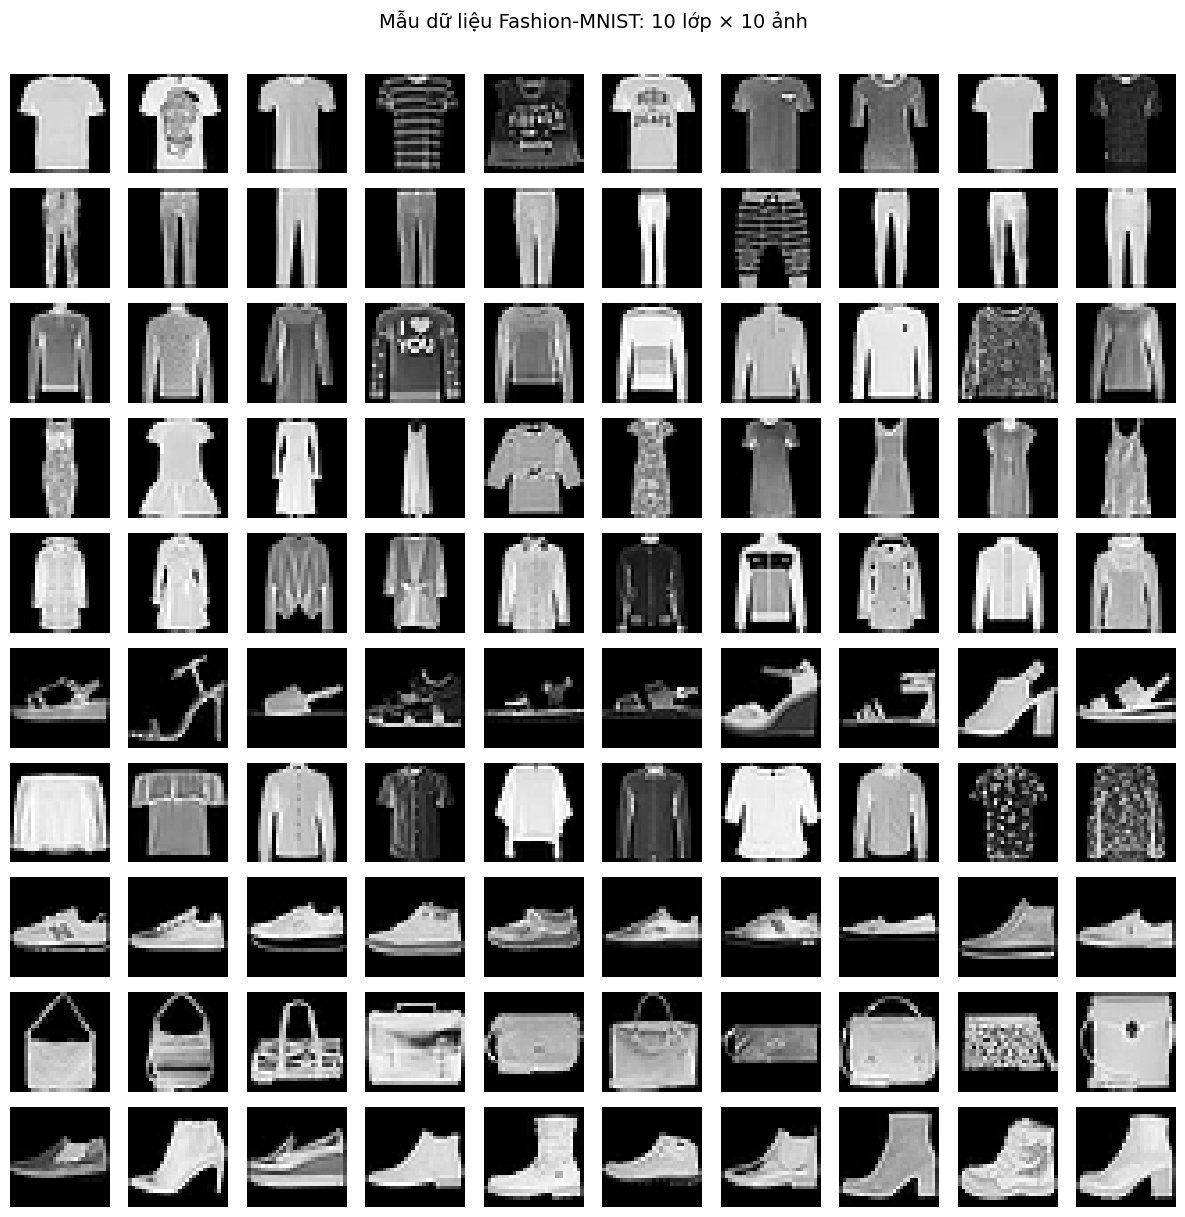

Đã lưu: results/fashion_mnist_samples.png


In [4]:
# Trực quan hóa 10 lớp × 10 ảnh
R, C = 10, 10
fig, axes = plt.subplots(R, C, figsize=(12, 12))
fig.suptitle("Mẫu dữ liệu Fashion-MNIST: 10 lớp × 10 ảnh", fontsize=14, y=1.01)

for label_class, plot_row in enumerate(axes):
    label_indices = np.where(tr_targets.numpy() == label_class)[0]
    for plot_cell in plot_row:
        plot_cell.grid(False)
        plot_cell.axis("off")
        ix = np.random.choice(label_indices)
        plot_cell.imshow(tr_images[ix], cmap="gray")
    plot_row[0].set_ylabel(class_names[label_class], fontsize=9, rotation=90)

plt.tight_layout()
plt.savefig(RESULT_DIR / "fashion_mnist_samples.png", dpi=180, bbox_inches="tight")
plt.show()

print("Đã lưu:", RESULT_DIR / "fashion_mnist_samples.png")


## 5. Xây dựng Dataset và DataLoader

Ảnh 28 × 28 sẽ được:
- Chuẩn hóa pixel từ `[0, 255]` về `[0, 1]`.
- Flatten từ ma trận `28 × 28` thành vector `784` chiều để đưa vào mạng nơ-ron fully connected.


In [5]:
class FMNISTDataset(Dataset):
    def __init__(self, images, labels):
        images = images.float() / 255.0
        images = images.view(-1, 28 * 28)
        self.x = images
        self.y = labels.long()

    def __getitem__(self, index):
        return self.x[index].to(device), self.y[index].to(device)

    def __len__(self):
        return len(self.x)


def get_data(batch_size=64):
    train_ds = FMNISTDataset(tr_images, tr_targets)
    test_ds = FMNISTDataset(test_images, test_targets)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader


train_loader, test_loader = get_data(batch_size=64)
sample_x, sample_y = next(iter(train_loader))

print(f"Số batch train: {len(train_loader)}")
print(f"Số batch test : {len(test_loader)}")
print(f"Kích thước 1 batch X: {sample_x.shape}")
print(f"Kích thước 1 batch Y: {sample_y.shape}")


Số batch train: 938
Số batch test : 157
Kích thước 1 batch X: torch.Size([64, 784])
Kích thước 1 batch Y: torch.Size([64])


## 6. Xây dựng mạng nơ-ron sâu

Kiến trúc sử dụng:

```text
Input 784
 → Linear 512 → BatchNorm → ReLU → Dropout
 → Linear 256 → BatchNorm → ReLU → Dropout
 → Linear 128 → BatchNorm → ReLU → Dropout
 → Linear 64  → BatchNorm → ReLU → Dropout
 → Linear 10
```

Ý nghĩa:
- **BatchNorm** giúp quá trình học ổn định hơn.
- **ReLU** tạo phi tuyến, giúp mô hình học quan hệ phức tạp.
- **Dropout** giảm overfitting.
- **CrossEntropyLoss** phù hợp với bài toán phân loại nhiều lớp.


In [6]:
class DeepNeuralNetwork(nn.Module):
    def __init__(self, input_size=784, num_classes=10):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(p=0.30),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.30),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.20),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=0.20),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)


def get_model(lr=1e-3):
    model = DeepNeuralNetwork().to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    return model, loss_fn, optimizer


model, loss_fn, optimizer = get_model()

print("=== KIẾN TRÚC MÔ HÌNH LAB 6 ===")
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTổng số tham số: {total_params:,}")
print(f"Số tham số huấn luyện: {trainable_params:,}")


=== KIẾN TRÚC MÔ HÌNH LAB 6 ===
DeepNeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.2, inplace=False)
    (16): Linear(in_features=64, out_features=10, bias=True)
  )
)

Tổng số tham số: 576,970

## 7. Định nghĩa hàm train, validate và accuracy

In [7]:
def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()
    epoch_losses = []
    correct = 0
    total = 0

    for x, y in loader:
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return np.mean(epoch_losses), correct / total


@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    losses = []
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    for x, y in loader:
        logits = model(x)
        loss = loss_fn(logits, y)
        losses.append(loss.item())

        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    return np.mean(losses), correct / total, np.array(all_preds), np.array(all_labels)


print("Đã định nghĩa hàm train/evaluate thành công.")


Đã định nghĩa hàm train/evaluate thành công.


## 8. Huấn luyện mô hình Lab 6 với Early Stopping

In [8]:
# Cấu hình huấn luyện
NUM_EPOCHS = 20
PATIENCE = 5
LEARNING_RATE = 1e-3

train_loader, test_loader = get_data(batch_size=64)
model, loss_fn, optimizer = get_model(lr=LEARNING_RATE)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": [],
    "learning_rate": []
}

best_test_loss = float("inf")
best_weights = None
patience_count = 0

print(f"Bắt đầu huấn luyện | Device: {device} | Epochs: {NUM_EPOCHS} | LR: {LEARNING_RATE}")
print("-" * 85)
print(f'{"Epoch":>5} | {"Train Loss":>10} | {"Train Acc":>10} | {"Test Loss":>10} | {"Test Acc":>9} | {"LR":>9}')
print("-" * 85)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, loss_fn)
    test_loss, test_acc, _, _ = evaluate(model, test_loader, loss_fn)

    scheduler.step(test_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)
    history["learning_rate"].append(current_lr)

    print(f"{epoch:>5} | {train_loss:>10.4f} | {train_acc:>9.2%} | {test_loss:>10.4f} | {test_acc:>8.2%} | {current_lr:>9.6f}")

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_weights = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"\nEarly stopping tại epoch {epoch}. Best test_loss = {best_test_loss:.4f}")
            break

# Nạp lại trọng số tốt nhất
if best_weights is not None:
    model.load_state_dict(best_weights)

history_df = pd.DataFrame(history)
history_df.to_csv(RESULT_DIR / "training_history.csv", index=False)

print("\nHoàn thành huấn luyện.")
print(f"Best test_loss: {best_test_loss:.4f}")
print("Đã lưu:", RESULT_DIR / "training_history.csv")


Bắt đầu huấn luyện | Device: cpu | Epochs: 20 | LR: 0.001
-------------------------------------------------------------------------------------
Epoch | Train Loss |  Train Acc |  Test Loss |  Test Acc |        LR
-------------------------------------------------------------------------------------
    1 |     0.5994 |    80.02% |     0.4610 |   82.84% |  0.001000
    2 |     0.4409 |    84.45% |     0.3881 |   86.07% |  0.001000
    3 |     0.4028 |    85.57% |     0.3782 |   86.17% |  0.001000
    4 |     0.3837 |    86.40% |     0.3661 |   86.57% |  0.001000
    5 |     0.3668 |    86.91% |     0.3825 |   85.84% |  0.001000
    6 |     0.3574 |    87.31% |     0.3599 |   86.26% |  0.001000
    7 |     0.3465 |    87.50% |     0.3370 |   87.50% |  0.001000
    8 |     0.3441 |    87.58% |     0.3485 |   87.09% |  0.001000
    9 |     0.3331 |    87.99% |     0.3332 |   87.46% |  0.001000
   10 |     0.3300 |    88.09% |     0.3336 |   87.67% |  0.001000
   11 |     0.3250 |    88.30% 

## 9. Trực quan hóa loss và accuracy

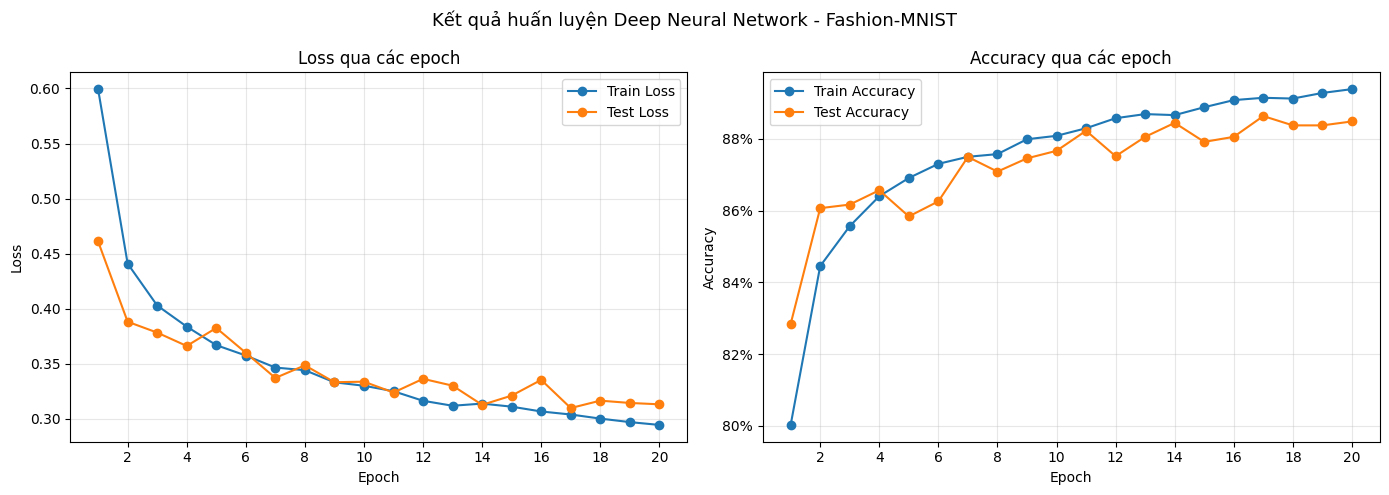

Kết quả cuối cùng:
Train Accuracy: 89.39%
Test Accuracy : 88.49%
Best Test Loss: 0.3097
Đã lưu: results/training_curves.png


In [9]:
epochs_range = history_df["epoch"].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Kết quả huấn luyện Deep Neural Network - Fashion-MNIST", fontsize=13)

axes[0].plot(epochs_range, history_df["train_loss"], "o-", label="Train Loss")
axes[0].plot(epochs_range, history_df["test_loss"], "o-", label="Test Loss")
axes[0].set_title("Loss qua các epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(2))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_df["train_acc"], "o-", label="Train Accuracy")
axes[1].plot(epochs_range, history_df["test_acc"], "o-", label="Test Accuracy")
axes[1].set_title("Accuracy qua các epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(2))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULT_DIR / "training_curves.png", dpi=180, bbox_inches="tight")
plt.show()

print("Kết quả cuối cùng:")
print(f"Train Accuracy: {history_df['train_acc'].iloc[-1]:.2%}")
print(f"Test Accuracy : {history_df['test_acc'].iloc[-1]:.2%}")
print(f"Best Test Loss: {best_test_loss:.4f}")
print("Đã lưu:", RESULT_DIR / "training_curves.png")


## 10. Đánh giá chi tiết: Confusion Matrix và Classification Report

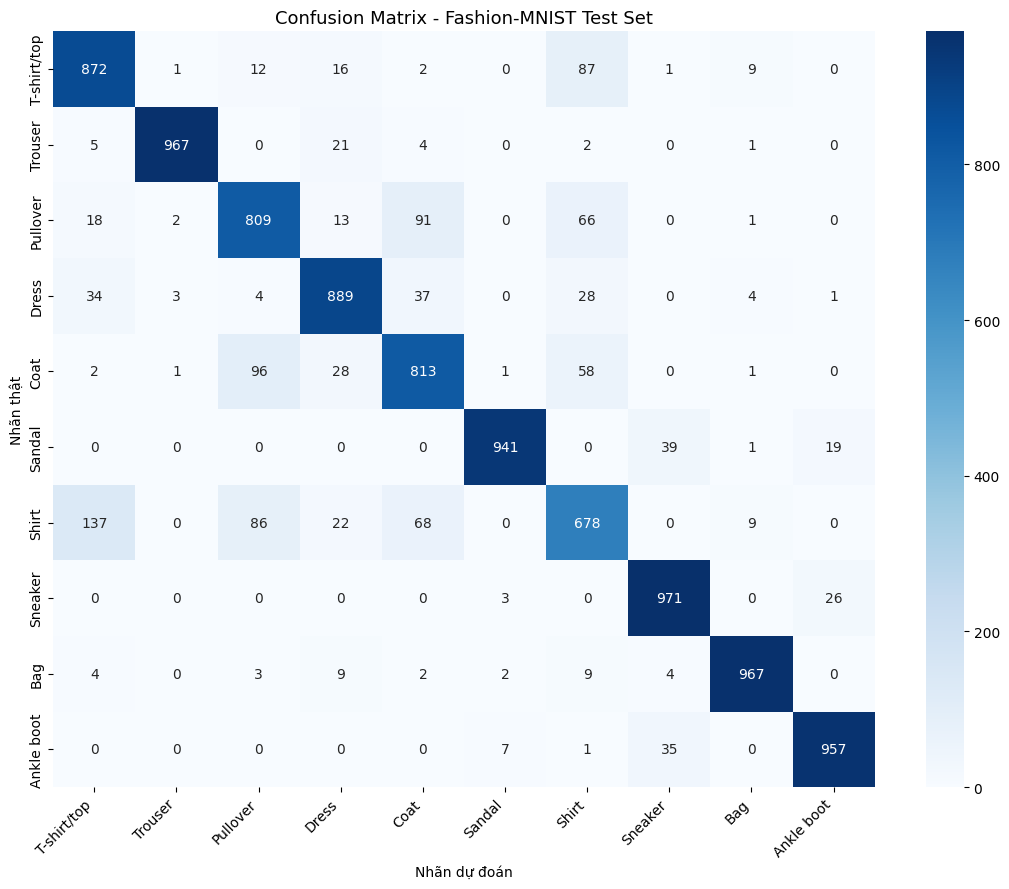

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 T-shirt/top       0.81      0.87      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.80      0.81      0.80      1000
       Dress       0.89      0.89      0.89      1000
        Coat       0.80      0.81      0.81      1000
      Sandal       0.99      0.94      0.96      1000
       Shirt       0.73      0.68      0.70      1000
     Sneaker       0.92      0.97      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.95      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

Test Accuracy: 88.64%
Đã lưu:
- results/confusion_matrix.png
- results/classification_report.txt
- results/classification_report.csv


In [10]:
test_loss, test_acc, all_preds, all_labels = evaluate(model, test_loader, loss_fn)

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(11, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix - Fashion-MNIST Test Set", fontsize=13)
plt.ylabel("Nhãn thật")
plt.xlabel("Nhãn dự đoán")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(RESULT_DIR / "confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

report_text = classification_report(all_labels, all_preds, target_names=class_names)
report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)

with open(RESULT_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report_text)

pd.DataFrame(report_dict).transpose().to_csv(RESULT_DIR / "classification_report.csv", encoding="utf-8-sig")

print("=== CLASSIFICATION REPORT ===")
print(report_text)
print("Test Accuracy:", f"{test_acc:.2%}")
print("Đã lưu:")
print("-", RESULT_DIR / "confusion_matrix.png")
print("-", RESULT_DIR / "classification_report.txt")
print("-", RESULT_DIR / "classification_report.csv")


## 11. Trực quan hóa kết quả dự đoán

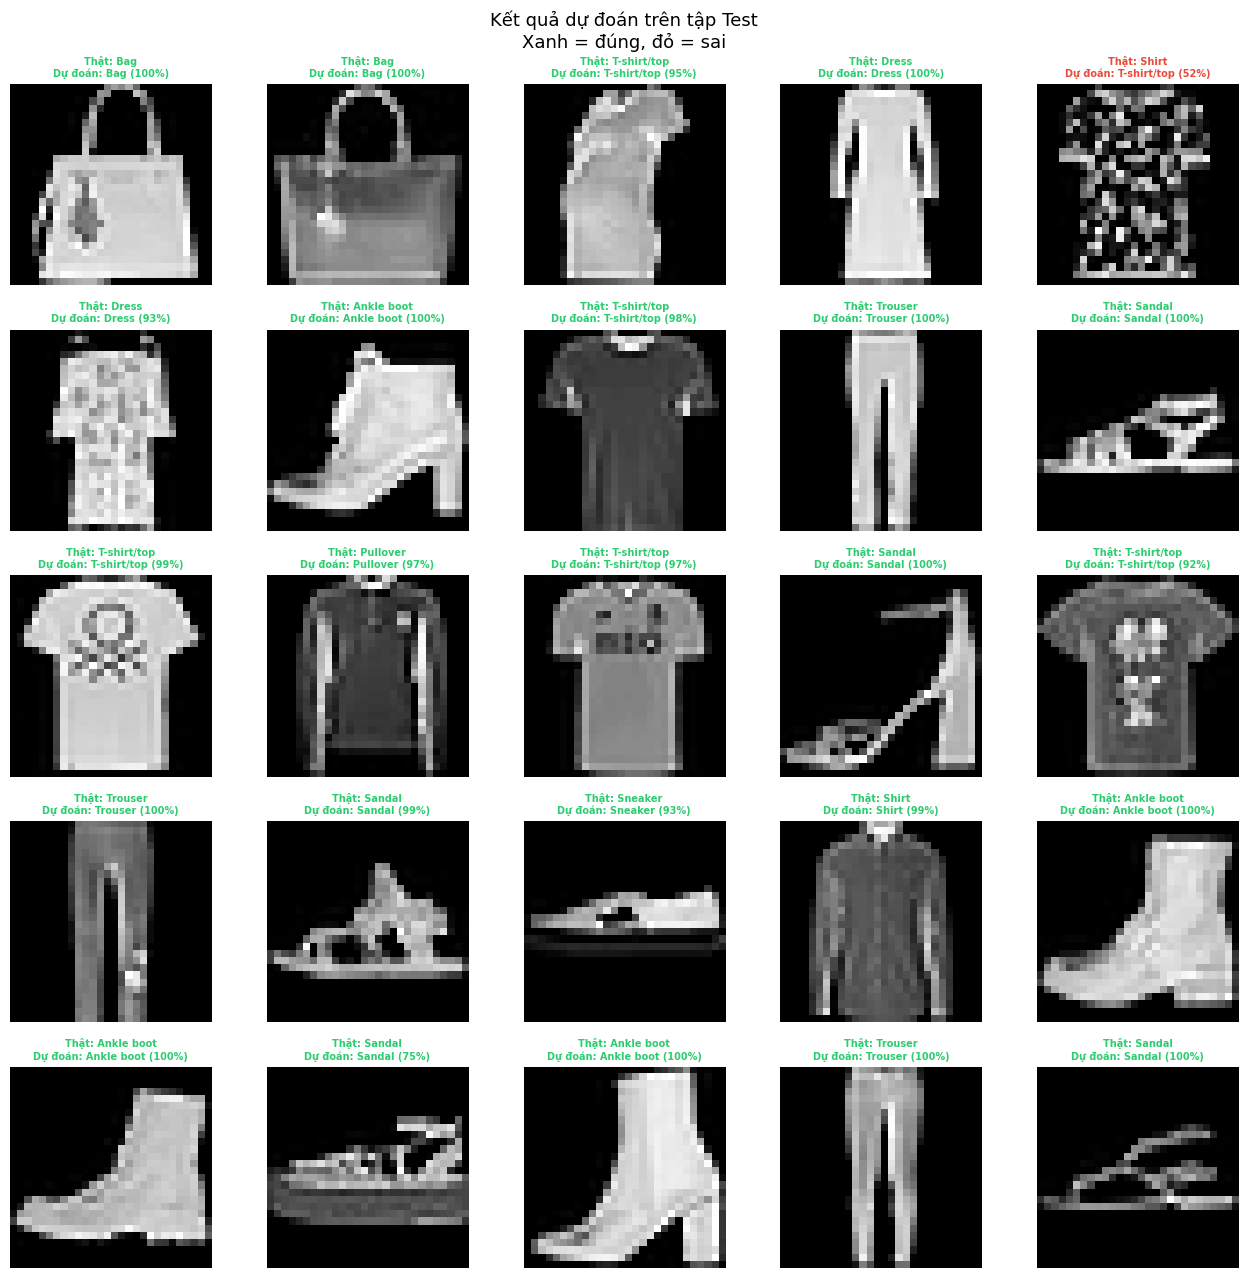

Đã lưu: results/prediction_samples.png


In [11]:
# Hiển thị 25 ảnh ngẫu nhiên cùng nhãn dự đoán và nhãn thật
n_samples = 25
indices = np.random.choice(len(test_images), n_samples, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(13, 13))
fig.suptitle("Kết quả dự đoán trên tập Test\nXanh = đúng, đỏ = sai", fontsize=13)

model.eval()
with torch.no_grad():
    for ax, idx in zip(axes.flat, indices):
        img = (test_images[idx].float() / 255.0).view(1, -1).to(device)
        true_label = test_targets[idx].item()

        output = model(img)
        proba = F.softmax(output, dim=-1)
        pred = output.argmax(dim=1).item()
        conf = proba[0, pred].item()

        ax.imshow(test_images[idx].numpy(), cmap="gray")
        ax.axis("off")

        color = "#2ecc71" if pred == true_label else "#e74c3c"
        ax.set_title(
            f"Thật: {class_names[true_label]}\nDự đoán: {class_names[pred]} ({conf:.0%})",
            fontsize=7,
            color=color,
            fontweight="bold"
        )

plt.tight_layout()
plt.savefig(RESULT_DIR / "prediction_samples.png", dpi=180, bbox_inches="tight")
plt.show()

print("Đã lưu:", RESULT_DIR / "prediction_samples.png")


## 12. So sánh Lab 5 và Lab 6

In [12]:
# Mô hình shallow neural network tương tự Lab 5 để so sánh
class ShallowNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(28 * 28, 1000),
            nn.ReLU(),
            nn.Linear(1000, 10)
        )

    def forward(self, x):
        return self.network(x)


shallow_model = ShallowNeuralNetwork().to(device)
shallow_loss_fn = nn.CrossEntropyLoss()
shallow_optimizer = Adam(shallow_model.parameters(), lr=1e-3)

shallow_history = {
    "epoch": [],
    "train_acc": [],
    "test_acc": []
}

print("Đang huấn luyện mô hình Lab 5 - Shallow NN để so sánh...")
for epoch in range(1, len(history_df) + 1):
    train_loss_s, train_acc_s = train_one_epoch(shallow_model, train_loader, shallow_optimizer, shallow_loss_fn)
    test_loss_s, test_acc_s, _, _ = evaluate(shallow_model, test_loader, shallow_loss_fn)

    shallow_history["epoch"].append(epoch)
    shallow_history["train_acc"].append(train_acc_s)
    shallow_history["test_acc"].append(test_acc_s)

    print(f"Epoch {epoch:02d} | Shallow Train Acc: {train_acc_s:.2%} | Shallow Test Acc: {test_acc_s:.2%}")

shallow_df = pd.DataFrame(shallow_history)

comparison_df = pd.DataFrame({
    "model": ["Lab5_Shallow_NN", "Lab6_Deep_NN"],
    "final_train_accuracy": [shallow_df["train_acc"].iloc[-1], history_df["train_acc"].iloc[-1]],
    "final_test_accuracy": [shallow_df["test_acc"].iloc[-1], history_df["test_acc"].iloc[-1]]
})

comparison_df["test_accuracy_improvement_vs_lab5"] = comparison_df["final_test_accuracy"] - comparison_df.loc[0, "final_test_accuracy"]
comparison_df.to_csv(RESULT_DIR / "lab5_vs_lab6_comparison.csv", index=False)

comparison_df


Đang huấn luyện mô hình Lab 5 - Shallow NN để so sánh...
Epoch 01 | Shallow Train Acc: 82.68% | Shallow Test Acc: 85.32%
Epoch 02 | Shallow Train Acc: 86.90% | Shallow Test Acc: 86.40%
Epoch 03 | Shallow Train Acc: 88.08% | Shallow Test Acc: 86.01%
Epoch 04 | Shallow Train Acc: 88.88% | Shallow Test Acc: 88.02%
Epoch 05 | Shallow Train Acc: 89.60% | Shallow Test Acc: 87.50%
Epoch 06 | Shallow Train Acc: 90.17% | Shallow Test Acc: 88.31%
Epoch 07 | Shallow Train Acc: 90.63% | Shallow Test Acc: 87.21%
Epoch 08 | Shallow Train Acc: 91.20% | Shallow Test Acc: 88.86%
Epoch 09 | Shallow Train Acc: 91.44% | Shallow Test Acc: 87.91%
Epoch 10 | Shallow Train Acc: 91.69% | Shallow Test Acc: 88.86%
Epoch 11 | Shallow Train Acc: 92.01% | Shallow Test Acc: 88.51%
Epoch 12 | Shallow Train Acc: 92.40% | Shallow Test Acc: 88.85%
Epoch 13 | Shallow Train Acc: 92.74% | Shallow Test Acc: 88.61%
Epoch 14 | Shallow Train Acc: 92.97% | Shallow Test Acc: 89.11%
Epoch 15 | Shallow Train Acc: 93.25% | Shallow 

,model,final_train_accuracy,final_test_accuracy,test_accuracy_improvement_vs_lab5
0,Lab5_Shallow_NN,0.943883,0.8947,0.0000
1,Lab6_Deep_NN,0.893917,0.8849,-0.0098


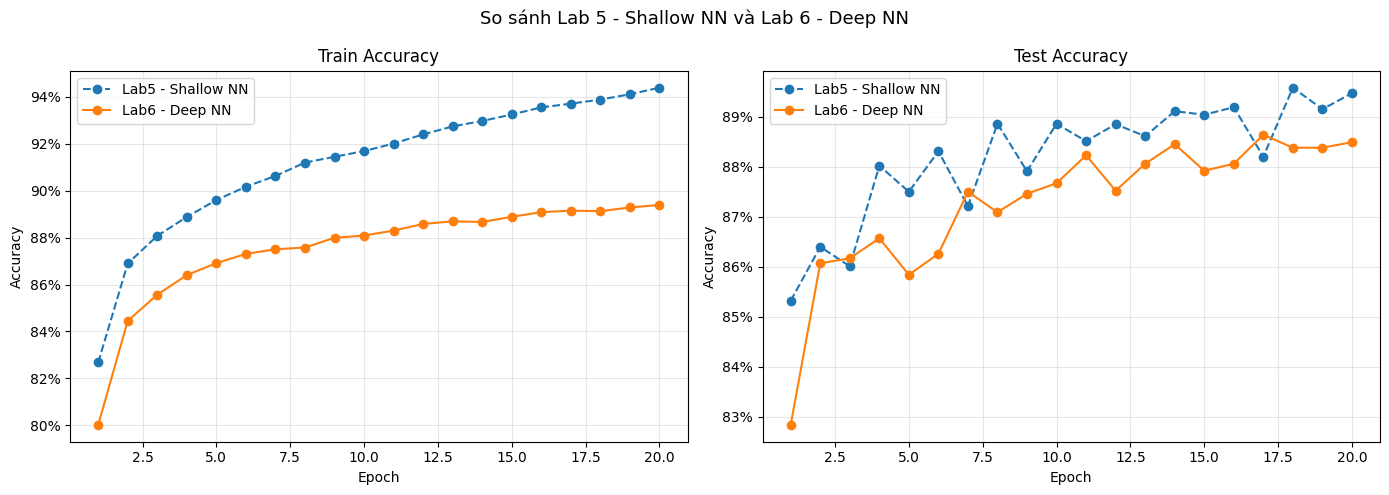

=== BẢNG SO SÁNH CUỐI CÙNG ===
             model  final_train_accuracy  final_test_accuracy  \
0  Lab5_Shallow_NN              0.943883               0.8947   
1     Lab6_Deep_NN              0.893917               0.8849   

   test_accuracy_improvement_vs_lab5  
0                             0.0000  
1                            -0.0098  
Đã lưu:
- results/lab5_vs_lab6_comparison.csv
- results/lab5_vs_lab6_accuracy.png


In [13]:
epochs_range = history_df["epoch"].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("So sánh Lab 5 - Shallow NN và Lab 6 - Deep NN", fontsize=13)

axes[0].plot(epochs_range, shallow_df["train_acc"], "o--", label="Lab5 - Shallow NN")
axes[0].plot(epochs_range, history_df["train_acc"], "o-", label="Lab6 - Deep NN")
axes[0].set_title("Train Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, shallow_df["test_acc"], "o--", label="Lab5 - Shallow NN")
axes[1].plot(epochs_range, history_df["test_acc"], "o-", label="Lab6 - Deep NN")
axes[1].set_title("Test Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULT_DIR / "lab5_vs_lab6_accuracy.png", dpi=180, bbox_inches="tight")
plt.show()

print("=== BẢNG SO SÁNH CUỐI CÙNG ===")
print(comparison_df)
print("Đã lưu:")
print("-", RESULT_DIR / "lab5_vs_lab6_comparison.csv")
print("-", RESULT_DIR / "lab5_vs_lab6_accuracy.png")


## 13. Lưu model và kiểm tra khả năng tải lại

In [14]:
model_path = MODEL_DIR / "lab6_deep_nn_fmnist.pth"
torch.save(model.state_dict(), model_path)

loaded_model = DeepNeuralNetwork().to(device)
loaded_model.load_state_dict(torch.load(model_path, map_location=device))
loaded_model.eval()

# Kiểm tra nhanh 1 batch
x_check, y_check = next(iter(test_loader))
with torch.no_grad():
    pred_check = loaded_model(x_check).argmax(dim=1)
    check_acc = (pred_check == y_check).float().mean().item()

print("Đã lưu model:", model_path)
print(f"Kiểm tra tải lại model thành công. Accuracy trên 1 batch test: {check_acc:.2%}")


Đã lưu model: models/lab6_deep_nn_fmnist.pth
Kiểm tra tải lại model thành công. Accuracy trên 1 batch test: 85.94%
